In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt

In [3]:
states_str = open("log/full_dpo_running_states.json").readline()
history = states_str.replace("\'", "\"")
history = json.loads(history)
history[-2:]

[{'loss': 0.0003,
  'grad_norm': 0.03195299580693245,
  'learning_rate': 3.854818796385495e-10,
  'rewards/chosen': 6.681591033935547,
  'rewards/rejected': -8.647468566894531,
  'rewards/accuracies': 1.0,
  'rewards/margins': 15.329058647155762,
  'logps/chosen': -608.1556396484375,
  'logps/rejected': -851.1854248046875,
  'logits/chosen': -3.2573254108428955,
  'logits/rejected': -3.236602783203125,
  'epoch': 0.9885696632684584,
  'step': 800},
 {'train_runtime': 1128.5534,
  'train_samples_per_second': 34.418,
  'train_steps_per_second': 0.717,
  'total_flos': 0.0,
  'train_loss': 0.00817346491241351,
  'epoch': 0.9996910719802286,
  'step': 809}]

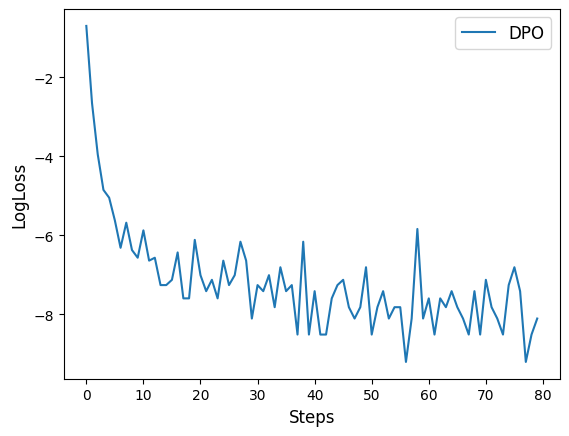

In [5]:
loss = [item["loss"] for item in history if "loss" in item]
plt.plot(np.log(loss), label="DPO")
plt.xlabel("Steps", fontsize=12)
plt.ylabel("LogLoss", fontsize=12)
plt.legend(fontsize=12)
plt.show()

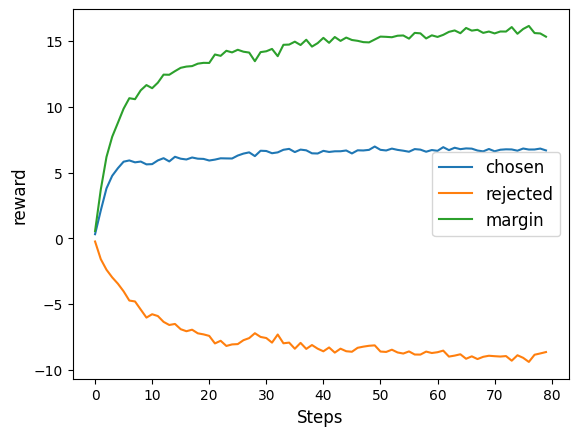

In [6]:
chosen_reward = [item["rewards/chosen"] for item in history if "rewards/chosen" in item]
rejected_reward = [item["rewards/rejected"] for item in history if "rewards/rejected" in item]
margins = [item["rewards/margins"] for item in history if "rewards/margins" in item]

plt.plot(chosen_reward, label="chosen")
plt.plot(rejected_reward, label="rejected")
plt.plot(margins, label="margin")
plt.xlabel("Steps", fontsize=12)
plt.ylabel("reward", fontsize=12)
plt.legend(fontsize=12)
plt.show()

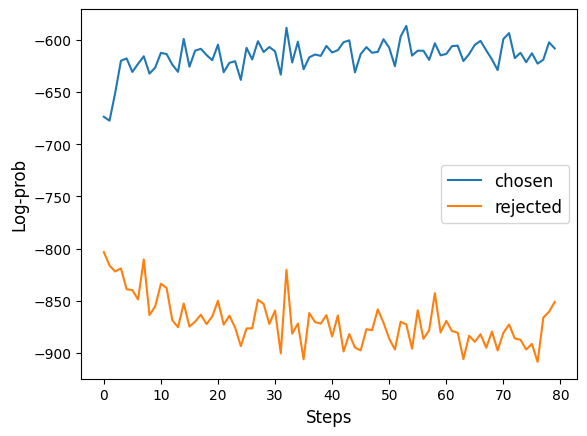

In [7]:
logps_chosen = [item["logps/chosen"] for item in history if "logps/chosen" in item]
logps_rejected = [item["logps/rejected"] for item in history if "logps/rejected" in item]

plt.plot(logps_chosen, label="chosen")
plt.plot(logps_rejected, label="rejected")
plt.xlabel("Steps", fontsize=12)
plt.ylabel("Log-prob", fontsize=12)
plt.legend(fontsize=12)
plt.show()

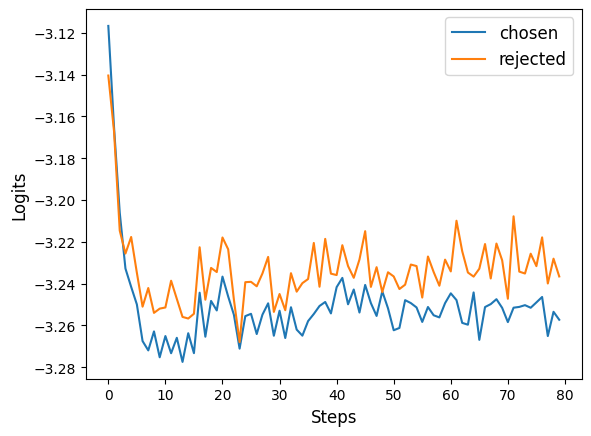

In [8]:
logits_chosen = [item["logits/chosen"] for item in history if "logits/chosen" in item]
logits_rejected = [item["logits/rejected"] for item in history if "logits/rejected" in item]

plt.plot(logits_chosen, label="chosen")
plt.plot(logits_rejected, label="rejected")
plt.xlabel("Steps", fontsize=12)
plt.ylabel("Logits", fontsize=12)
plt.legend(fontsize=12)
plt.show()